In [2]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [3]:
df = pd.DataFrame()

In [4]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [5]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

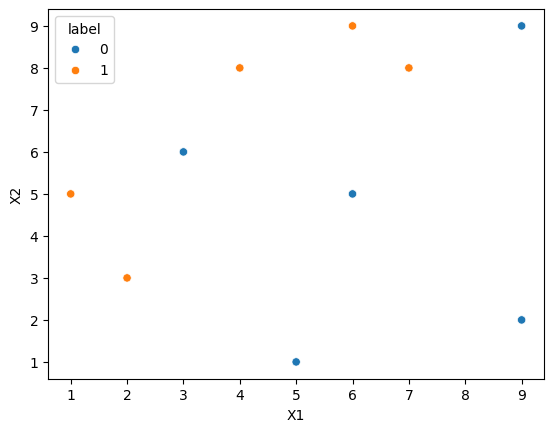

In [6]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [7]:
df['weights'] = 1/df.shape[0]

In [8]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [11]:
X= df.iloc[:,0:2].values
y = df.iloc[:,2].values


In [12]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

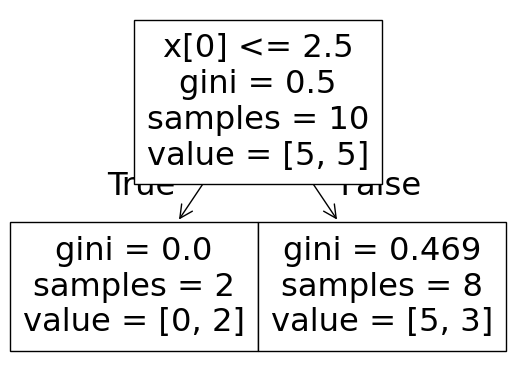

In [13]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

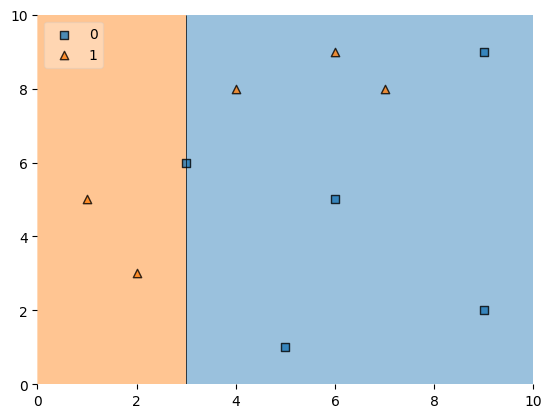

In [14]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [15]:
df['y_pred'] = dt1.predict(X)

In [16]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [17]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.00000001))

In [18]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.4236489135269354)

In [19]:
def update_row_weights(row,alpha = 0.423):
    if row['label'] == row['y_pred']:
        return row["weights"]*np.exp(-alpha)
    else:
        return row["weights"]*np.exp(alpha)

In [20]:
df['updatwd_weights'] = df.apply(update_row_weights,axis=1)

In [21]:
df

,X1,X2,label,weights,y_pred,updatwd_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [22]:
df['updatwd_weights'].sum()

np.float64(0.9165153319682015)

In [23]:
df['normalized_weights'] = df['updatwd_weights']/df['updatwd_weights'].sum()

In [24]:
df['normalized_weights'].sum()

np.float64(1.0)

In [25]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [26]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [27]:
df

,X1,X2,label,weights,y_pred,updatwd_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [28]:
def create_new_dataset(df):

    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [29]:
index_values = create_new_dataset(df)

index_values

[9, 3, 5, 0, 6, 7, 5, 6, 7, 7]

In [30]:
second_df = df.iloc[index_values,0:4]

In [31]:
second_df

,X1,X2,label,weights
9,9,2,0,0.1
3,4,8,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1


In [32]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [33]:
X= second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [34]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 6.5\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.625, 0.5, '  False')]

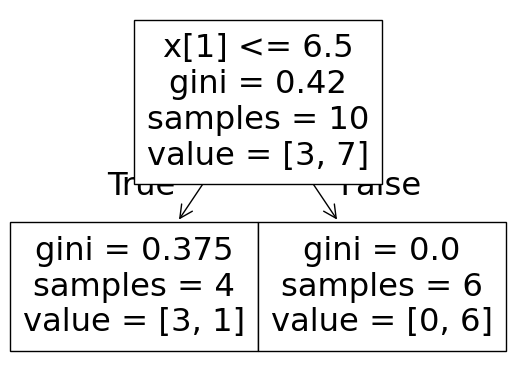

In [35]:
plot_tree(dt2)

<Axes: >

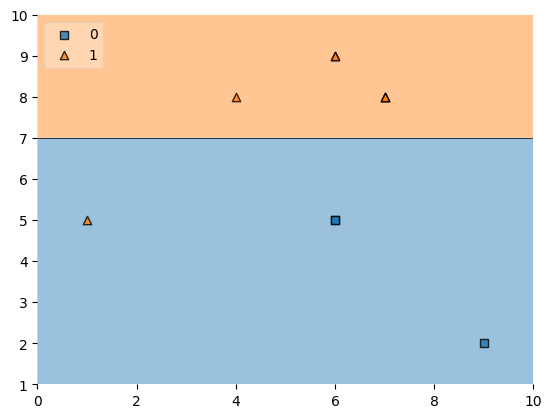

In [36]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [37]:
second_df['y_pred'] = dt2.predict(X)

In [38]:
second_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
3,4,8,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,1
5,6,9,1,0.1,1
6,6,5,0,0.1,0
7,7,8,1,0.1,1
7,7,8,1,0.1,1


In [39]:
alpha2 = calculate_model_weight(0.1)

In [40]:
alpha2

np.float64(1.0986122386681123)

In [41]:
def update_row_weights(row,alpha = 1.09):
    if row['label'] == row['y_pred']:
        return row["weights"]*np.exp(-alpha)
    else:
        return row["weights"]*np.exp(alpha)

In [43]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [44]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [45]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
9,9,2,0,0.1,0,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,0,0.297427,0.495694
6,6,5,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034


In [46]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [47]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [48]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
9,9,2,0,0.1,0,0.033622,0.056034,0.056034,0.000000
3,4,8,1,0.1,1,0.033622,0.056034,0.112068,0.056034
5,6,9,1,0.1,1,0.033622,0.056034,0.168102,0.112068
0,1,5,1,0.1,0,0.297427,0.495694,0.663796,0.168102
6,6,5,0,0.1,0,0.033622,0.056034,0.719830,0.663796
7,7,8,1,0.1,1,0.033622,0.056034,0.775864,0.719830
5,6,9,1,0.1,1,0.033622,0.056034,0.831898,0.775864
6,6,5,0,0.1,0,0.033622,0.056034,0.887932,0.831898
7,7,8,1,0.1,1,0.033622,0.056034,0.943966,0.887932
7,7,8,1,0.1,1,0.033622,0.056034,1.000000,0.943966


In [53]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)


array([1])

In [52]:
dt2.predict(query)

array([0])

In [ ]:
np.sign(alpha1*(1) + alpha2*(-1))

np.float64(-0.6749633251411769)

In [55]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [56]:
dt2.predict(query)

array([1])

In [57]:
np.sign(alpha1*(-1) + alpha2*(1))

np.float64(1.0)